In [6]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image
from scipy import stats
from xbbg import blp
from datetime import datetime, timedelta

from scipy.stats import percentileofscore

from pandas.tseries.offsets import Week, MonthEnd, Day

In [ ]:
def PullHistoricalATMVols(ccys, tenors, start_year, end_year):
    start_date = f"{start_year}-01-01"
    end_date = f"{end_year}-12-31"
    all_data = pd.DataFrame()
    vol_types = {'V': 'IV', 'H': 'RV'}
    for ccy in ccys:
        for tenor in tenors:
            for vol_code, vol_label in vol_types.items():
                ticker = f"{ccy}{vol_code}{tenor} BGN Curncy"
                data = blp.bdh(
                    tickers=ticker,
                    flds="PX_LAST",
                    start_date=start_date,
                    end_date=end_date)
                col_name = f"{ccy}_{tenor}_{vol_label}"
                data.columns = [col_name]
                if all_data.empty:
                    all_data = data
                else:
                    all_data = all_data.join(data, how='outer')
    return all_data

def parse_tenor_to_offset(tenor_str):
    if 'W' in tenor_str:
        weeks = int(tenor_str.replace('W', ''))
        return Week(weeks)
    elif 'M' in tenor_str:
        months = int(tenor_str.replace('M', ''))
        return MonthEnd(months)
    elif 'D' in tenor_str:
        days = int(tenor_str.replace('D', ''))
        return Day(days)
    return None

def extract_tenor(col_name):
    parts = col_name.split('_')
    if len(parts) >= 2:
        return parts[1]
    return None

def get_aligned_vol_data(ccys, tenors, start_year, end_year, months=None):
    max_tenor_days = max([
        int(t.replace('W', '')) * 7 if 'W' in t else 
        int(t.replace('M', '')) * 30 if 'M' in t else 0 
        for t in tenors])
    buffer_months = max(3, (max_tenor_days // 30) + 3)  # At least 3 months
    data_pull_end_year = end_year + (buffer_months // 12 + 1)
    historical_data = PullHistoricalATMVols(
        ccys, 
        tenors, 
        start_year=start_year, 
        end_year=data_pull_end_year)
    historical_data.index = pd.to_datetime(historical_data.index)
    def get_nearest_rv(target_date, rv_series, max_days=5):
        if pd.isna(target_date):
            return None
        if target_date in rv_series.index:
            return rv_series[target_date]
        for offset in range(1, max_days + 1):
            future_date = target_date + pd.Timedelta(days=offset)
            if future_date in rv_series.index:
                return rv_series[future_date]
            past_date = target_date - pd.Timedelta(days=offset)
            if past_date in rv_series.index:
                return rv_series[past_date]
        return None
    aligned_data = pd.DataFrame(index=historical_data.index)
    iv_cols = [col for col in historical_data.columns if '_IV' in col]
    rv_cols = [col for col in historical_data.columns if '_RV' in col]
    for iv_col in iv_cols:
        rv_col = iv_col.replace('_IV', '_RV')
        if rv_col in rv_cols:
            tenor = extract_tenor(iv_col)
            if tenor:
                offset = parse_tenor_to_offset(tenor)
                if offset:
                    iv_data = historical_data[iv_col].copy()
                    rv_current = historical_data[rv_col].copy()
                    target_dates = iv_data.index + offset
                    
                    temp_df = pd.DataFrame({
                        'date': iv_data.index,
                        'target_date': target_dates,
                        'IV': iv_data.values,
                        'RV_current': rv_current.values})
                    
                    rv_lookup = historical_data[rv_col].copy()
                    
                    # Use nearest RV lookup with fallback
                    temp_df['RV_forward'] = temp_df['target_date'].apply(
                        lambda x: get_nearest_rv(x, rv_lookup, max_days=5))
                    
                    base_name = iv_col.replace('_IV', '')
                    aligned_data[f'{base_name}_IV'] = temp_df.set_index('date')['IV']
                    aligned_data[f'{base_name}_RV_current'] = temp_df.set_index('date')['RV_current']
                    aligned_data[f'{base_name}_RV_forward'] = temp_df.set_index('date')['RV_forward']
                    aligned_data[f'{base_name}_premium'] = (
                        temp_df.set_index('date')['IV'] - temp_df.set_index('date')['RV_forward'])
                    aligned_data[f'{base_name}_IV_minus_current_RV'] = (
                        temp_df.set_index('date')['IV'] - temp_df.set_index('date')['RV_current'])
                    aligned_data[f'{base_name}_target_date'] = temp_df.set_index('date')['target_date']
    
    # Filter to desired period
    if months is not None:
        period_mask = (
            (aligned_data.index.month.isin(months)) &
            (aligned_data.index.year >= start_year) &
            (aligned_data.index.year <= end_year))
        period_data = aligned_data[period_mask].copy()
    else:
        period_mask = (
            (aligned_data.index.year >= start_year) &
            (aligned_data.index.year <= end_year))
        period_data = aligned_data[period_mask].copy()
    
    # Add time columns
    period_data['Year'] = period_data.index.year
    period_data['Month'] = period_data.index.month
    period_data['Day_of_Week'] = period_data.index.dayofweek
    
    if months is not None and len(months) > 0:
        first_month = min(months)
        period_data['Period_Week'] = period_data.index.map(
            lambda x: (x.month - first_month) * 4 + (x.day - 1) // 7 + 1)
    
    period_data['Day_of_Month'] = period_data.index.day
    period_data['Week_of_Year'] = period_data.index.isocalendar().week
    period_data['Day_Name'] = period_data.index.day_name()
    period_data['Month_Day'] = period_data.index.strftime('%m-%d')
    period_data['Q4_Week_Num'] = period_data.index.map(
        lambda x: (x.month - 10) * 4 + (x.day - 1) // 7 + 1)
    period_data['Week_in_Month'] = ((period_data['Day_of_Month'] - 1) // 7) + 1
    return period_data


In [8]:
# -----------------------------------------------------------------------------------
# -----------------------------------------------------------------------------------
# -----------------------------------------------------------------------------------

In [9]:
def panel_regression_with_plots(data, ccys, tenors):

    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    import matplotlib.pyplot as plt
    import numpy as np
    print("\n" + "="*80)
    print("PANEL REGRESSION WITH YEAR FIXED EFFECTS")
    print("Controls for the fact that each year has different baseline vol levels")
    print("="*80)
    week_labels = {
        1: 'Oct\nW1', 2: 'Oct\nW2', 3: 'Oct\nW3', 4: 'Oct\nW4',
        5: 'Oct W5/\nNov W1', 6: 'Nov\nW2', 7: 'Nov\nW3', 8: 'Nov\nW4', 
        9: 'Nov W5/\nDec W1', 10: 'Dec\nW2', 11: 'Dec\nW3', 12: 'Dec\nW4', 
        13: 'Dec\nW5'}
    fig, axes = plt.subplots(len(ccys), len(tenors), 
                             figsize=(7*len(tenors), 5*len(ccys)))
    if len(ccys) == 1 and len(tenors) == 1:
        axes = np.array([[axes]])
    elif len(ccys) == 1:
        axes = axes.reshape(1, -1)
    elif len(tenors) == 1:
        axes = axes.reshape(-1, 1)
    
    # Create dummy handles for figure-level legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='IV Median',
               markerfacecolor='blue', markeredgecolor='darkblue', 
               markersize=8, markeredgewidth=1.5),
        Line2D([0], [0], marker='s', color='w', label='RV Median',
               markerfacecolor='red', markeredgecolor='darkred', 
               markersize=8, markeredgewidth=1.5),
        Line2D([0], [0], color='blue', linewidth=3, label='IV Trend'),
        Line2D([0], [0], color='red', linewidth=3, label='RV Trend'),
        Line2D([0], [0], marker='o', color='w', label='Vol Premium (IV-RV)',
               markerfacecolor='lightgreen', markeredgecolor='darkgreen', 
               markersize=8, markeredgewidth=0.5, alpha=0.6)
    ]
    
    for ccy_idx, ccy in enumerate(ccys):
        print(f"\n{'='*80}")
        print(f"CURRENCY PAIR: {ccy}")
        print(f"{'='*80}")
        for tenor_idx, tenor in enumerate(tenors):
            ax = axes[ccy_idx, tenor_idx]   
            iv_col = f'{ccy}_{tenor}_IV'
            rv_col = f'{ccy}_{tenor}_RV_forward'
            premium_col = f'{ccy}_{tenor}_premium'
            
            if iv_col not in data.columns or rv_col not in data.columns:
                ax.text(0.5, 0.5, f'No data for\n{ccy} {tenor}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='red')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # ===================================================================
            # PANEL REGRESSION FOR IMPLIED VOL
            # ===================================================================
            
            reg_data_iv = data[['Q4_Week_Num', 'Year', iv_col]].dropna().copy()
            reg_data_iv.columns = ['Week', 'Year', 'Vol']
            reg_data_iv['Year'] = reg_data_iv['Year'].astype(str)
            
            if len(reg_data_iv) < 20:  # Not enough data
                ax.text(0.5, 0.5, f'Insufficient data\n{ccy} {tenor}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='orange')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            model_iv = smf.ols('Vol ~ Week + C(Year)', data=reg_data_iv).fit()
            
            # ===================================================================
            # PANEL REGRESSION FOR REALIZED VOL
            # ===================================================================
            
            reg_data_rv = data[['Q4_Week_Num', 'Year', rv_col]].dropna().copy()
            reg_data_rv.columns = ['Week', 'Year', 'Vol']
            reg_data_rv['Year'] = reg_data_rv['Year'].astype(str)
            
            model_rv = smf.ols('Vol ~ Week + C(Year)', data=reg_data_rv).fit()
            
            # Print results
            print(f"\n{tenor}:")
            print(f"  IV: Slope={model_iv.params['Week']:.4f}, "
                  f"p={model_iv.pvalues['Week']:.4f}, "
                  f"Adj R²={model_iv.rsquared_adj:.3f}")
            print(f"  RV: Slope={model_rv.params['Week']:.4f}, "
                  f"p={model_rv.pvalues['Week']:.4f}, "
                  f"Adj R²={model_rv.rsquared_adj:.3f}")
            
            # ===================================================================
            # PLOTTING - CLEANER VERSION
            # ===================================================================
            
            weeks_plot = np.linspace(1, 13, 100)
            
            # Calculate trend lines
            mean_year_effect_iv = np.mean([model_iv.params[f'C(Year)[T.{y}]'] 
                                            for y in reg_data_iv['Year'].unique()[1:]] + [0])
            trend_iv = model_iv.params['Intercept'] + model_iv.params['Week'] * weeks_plot + mean_year_effect_iv
            
            mean_year_effect_rv = np.mean([model_rv.params[f'C(Year)[T.{y}]'] 
                                            for y in reg_data_rv['Year'].unique()[1:]] + [0])
            trend_rv = model_rv.params['Intercept'] + model_rv.params['Week'] * weeks_plot + mean_year_effect_rv
            
            # Calculate data for each week
            iv_weekly_by_year = []
            rv_weekly_by_year = []
            premium_weekly_by_year = []
            
            for week in range(1, 14):
                week_data = data[data['Q4_Week_Num'] == week]
                if len(week_data) > 0:
                    iv_vals = week_data[iv_col].dropna().values
                    rv_vals = week_data[rv_col].dropna().values
                    
                    # Get premium values
                    if premium_col in data.columns:
                        prem_vals = week_data[premium_col].dropna().values
                    else:
                        prem_vals = []
                    
                    iv_weekly_by_year.append(iv_vals)
                    rv_weekly_by_year.append(rv_vals)
                    premium_weekly_by_year.append(prem_vals)
                else:
                    iv_weekly_by_year.append([])
                    rv_weekly_by_year.append([])
                    premium_weekly_by_year.append([])
            
            # Calculate medians for each week
            weeks_with_data = []
            iv_p50, rv_p50 = [], []
            
            for week in range(1, 14):
                if len(iv_weekly_by_year[week-1]) > 2:
                    weeks_with_data.append(week)
                    iv_p50.append(np.percentile(iv_weekly_by_year[week-1], 50))
                    rv_p50.append(np.percentile(rv_weekly_by_year[week-1], 50))
            
            # Plot median points for IV and RV (without labels in subplot)
            ax.scatter(weeks_with_data, iv_p50, s=80, color='blue', 
                      marker='o', edgecolors='darkblue', linewidth=1.5, 
                      alpha=0.7, zorder=5)
            ax.scatter(weeks_with_data, rv_p50, s=80, color='red', 
                      marker='s', edgecolors='darkred', linewidth=1.5, 
                      alpha=0.7, zorder=5)
            
            # Plot panel regression trend lines (without labels in subplot)
            ax.plot(weeks_plot, trend_iv, 'b-', linewidth=3, alpha=0.9, zorder=10)
            ax.plot(weeks_plot, trend_rv, 'r-', linewidth=3, alpha=0.9, zorder=10)
            
            # ===================================================================
            # ADD SECONDARY Y-AXIS FOR PREMIUM
            # ===================================================================
            
            ax2 = ax.twinx()
            
            # Plot ALL individual premium values as light green circles (without labels)
            for week in range(1, 14):
                if len(premium_weekly_by_year[week-1]) > 0:
                    # Add small random jitter to x-coordinates to avoid overlap
                    x_jitter = week + np.random.uniform(-0.15, 0.15, len(premium_weekly_by_year[week-1]))
                    
                    ax2.scatter(x_jitter, premium_weekly_by_year[week-1], 
                               s=60, color='lightgreen', marker='o', 
                               edgecolors='darkgreen', linewidth=0.5, 
                               alpha=0.6, zorder=3)
            
            # Add horizontal line at 0 for premium
            ax2.axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.6)
            
            # Format secondary y-axis
            ax2.set_ylabel('Vol Premium (IV - RV)', fontsize=9, fontweight='bold', color='darkgreen')
            ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=8)
            
            # Center the y-axis at 0
            all_premium_values = []
            for week_prems in premium_weekly_by_year:
                all_premium_values.extend([p for p in week_prems if not np.isnan(p)])
            
            if len(all_premium_values) > 0:
                max_abs_premium = max(abs(min(all_premium_values)), abs(max(all_premium_values)))
                ax2.set_ylim(-max_abs_premium * 1.2, max_abs_premium * 1.2)
            
            # ===================================================================
            # Add trend info and R² in CLEAR box on top right
            # ===================================================================
            
            sig_iv = "***" if model_iv.pvalues['Week'] < 0.001 else "**" if model_iv.pvalues['Week'] < 0.01 else "*" if model_iv.pvalues['Week'] < 0.05 else "n.s."
            sig_rv = "***" if model_rv.pvalues['Week'] < 0.001 else "**" if model_rv.pvalues['Week'] < 0.01 else "*" if model_rv.pvalues['Week'] < 0.05 else "n.s."
            
            # Enhanced info box with slopes clearly shown
            info_text = (
                f"IV Trend: {model_iv.params['Week']:+.4f}/wk {sig_iv}\n"
                f"   R² = {model_iv.rsquared_adj:.3f}\n"
                f"RV Trend: {model_rv.params['Week']:+.4f}/wk {sig_rv}\n"
                f"   R² = {model_rv.rsquared_adj:.3f}"
            )
            
            ax.text(0.98, 0.98, info_text, transform=ax.transAxes, 
                   fontsize=9, va='top', ha='right', family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                            alpha=0.95, edgecolor='black', linewidth=1.5))
            
            # ===================================================================
            # Labels and formatting
            # ===================================================================
            
            # X-axis label on ALL subplots
            ax.set_xlabel('Q4 Week', fontsize=10, fontweight='bold')
            
            if tenor_idx == 0:  # Left column
                ax.set_ylabel(f'{ccy}\nVolatility', fontsize=10, fontweight='bold')
            
            # Title only on top row
            if ccy_idx == 0:
                ax.set_title(f'{tenor}', fontsize=12, fontweight='bold', pad=10)
            
            ax.grid(True, alpha=0.3)
            ax.set_xticks(range(1, 14))
            
            # X-axis labels on ALL subplots
            ax.set_xticklabels([week_labels.get(i, f'W{i}') for i in range(1, 14)], 
                              fontsize=7, rotation=0)
    
    # Add figure-level legend
    fig.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, 0.98), ncol=5, fontsize=10, 
              frameon=True, fancybox=True, shadow=True)
    
    # Add overall title with space for legend
    fig.suptitle('Panel Regression: Q4 Volatility Trends by Currency & Tenor', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for legend
    plt.show()

In [11]:
q4_data = get_aligned_vol_data(
            ccys=        ['EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'AUDUSD', 'NZDUSD', 'USDMXN', 'USDBRL'],
            tenors=      ['1W', '2W', '1M'],
            start_year=  2015,
            end_year=    2024,
            months=      [10, 11, 12])

C:\Users\ntaylor\AppData\Local\Temp\ipykernel_36752\121361064.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aligned_data[f'{base_name}_IV_minus_current_RV'] = (
C:\Users\ntaylor\AppData\Local\Temp\ipykernel_36752\121361064.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aligned_data[f'{base_name}_target_date'] = temp_df.set_index('date')['target_date']
C:\Users\ntaylor\AppData\Local\Temp\ipykernel_36752\121361064.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame


PANEL REGRESSION WITH YEAR FIXED EFFECTS
Controls for the fact that each year has different baseline vol levels

CURRENCY PAIR: EURUSD

1W:
  IV: Slope=-0.0130, p=0.4785, Adj R²=0.583
  RV: Slope=0.0072, p=0.7245, Adj R²=0.551

2W:
  IV: Slope=-0.0167, p=0.2579, Adj R²=0.686
  RV: Slope=0.0089, p=0.5688, Adj R²=0.685

1M:
  IV: Slope=-0.0349, p=0.0010, Adj R²=0.806
  RV: Slope=0.0536, p=0.0000, Adj R²=0.800

CURRENCY PAIR: USDJPY

1W:
  IV: Slope=-0.0128, p=0.5642, Adj R²=0.628
  RV: Slope=0.0872, p=0.0055, Adj R²=0.485

2W:
  IV: Slope=-0.0217, p=0.1999, Adj R²=0.733
  RV: Slope=0.1110, p=0.0000, Adj R²=0.644

1M:
  IV: Slope=-0.0597, p=0.0000, Adj R²=0.870
  RV: Slope=0.0873, p=0.0000, Adj R²=0.795

CURRENCY PAIR: GBPUSD

1W:
  IV: Slope=-0.1290, p=0.0000, Adj R²=0.515
  RV: Slope=-0.1375, p=0.0000, Adj R²=0.463

2W:
  IV: Slope=-0.1159, p=0.0000, Adj R²=0.582
  RV: Slope=-0.1088, p=0.0000, Adj R²=0.566

1M:
  IV: Slope=-0.1193, p=0.0000, Adj R²=0.714
  RV: Slope=-0.0506, p=0.0041, 

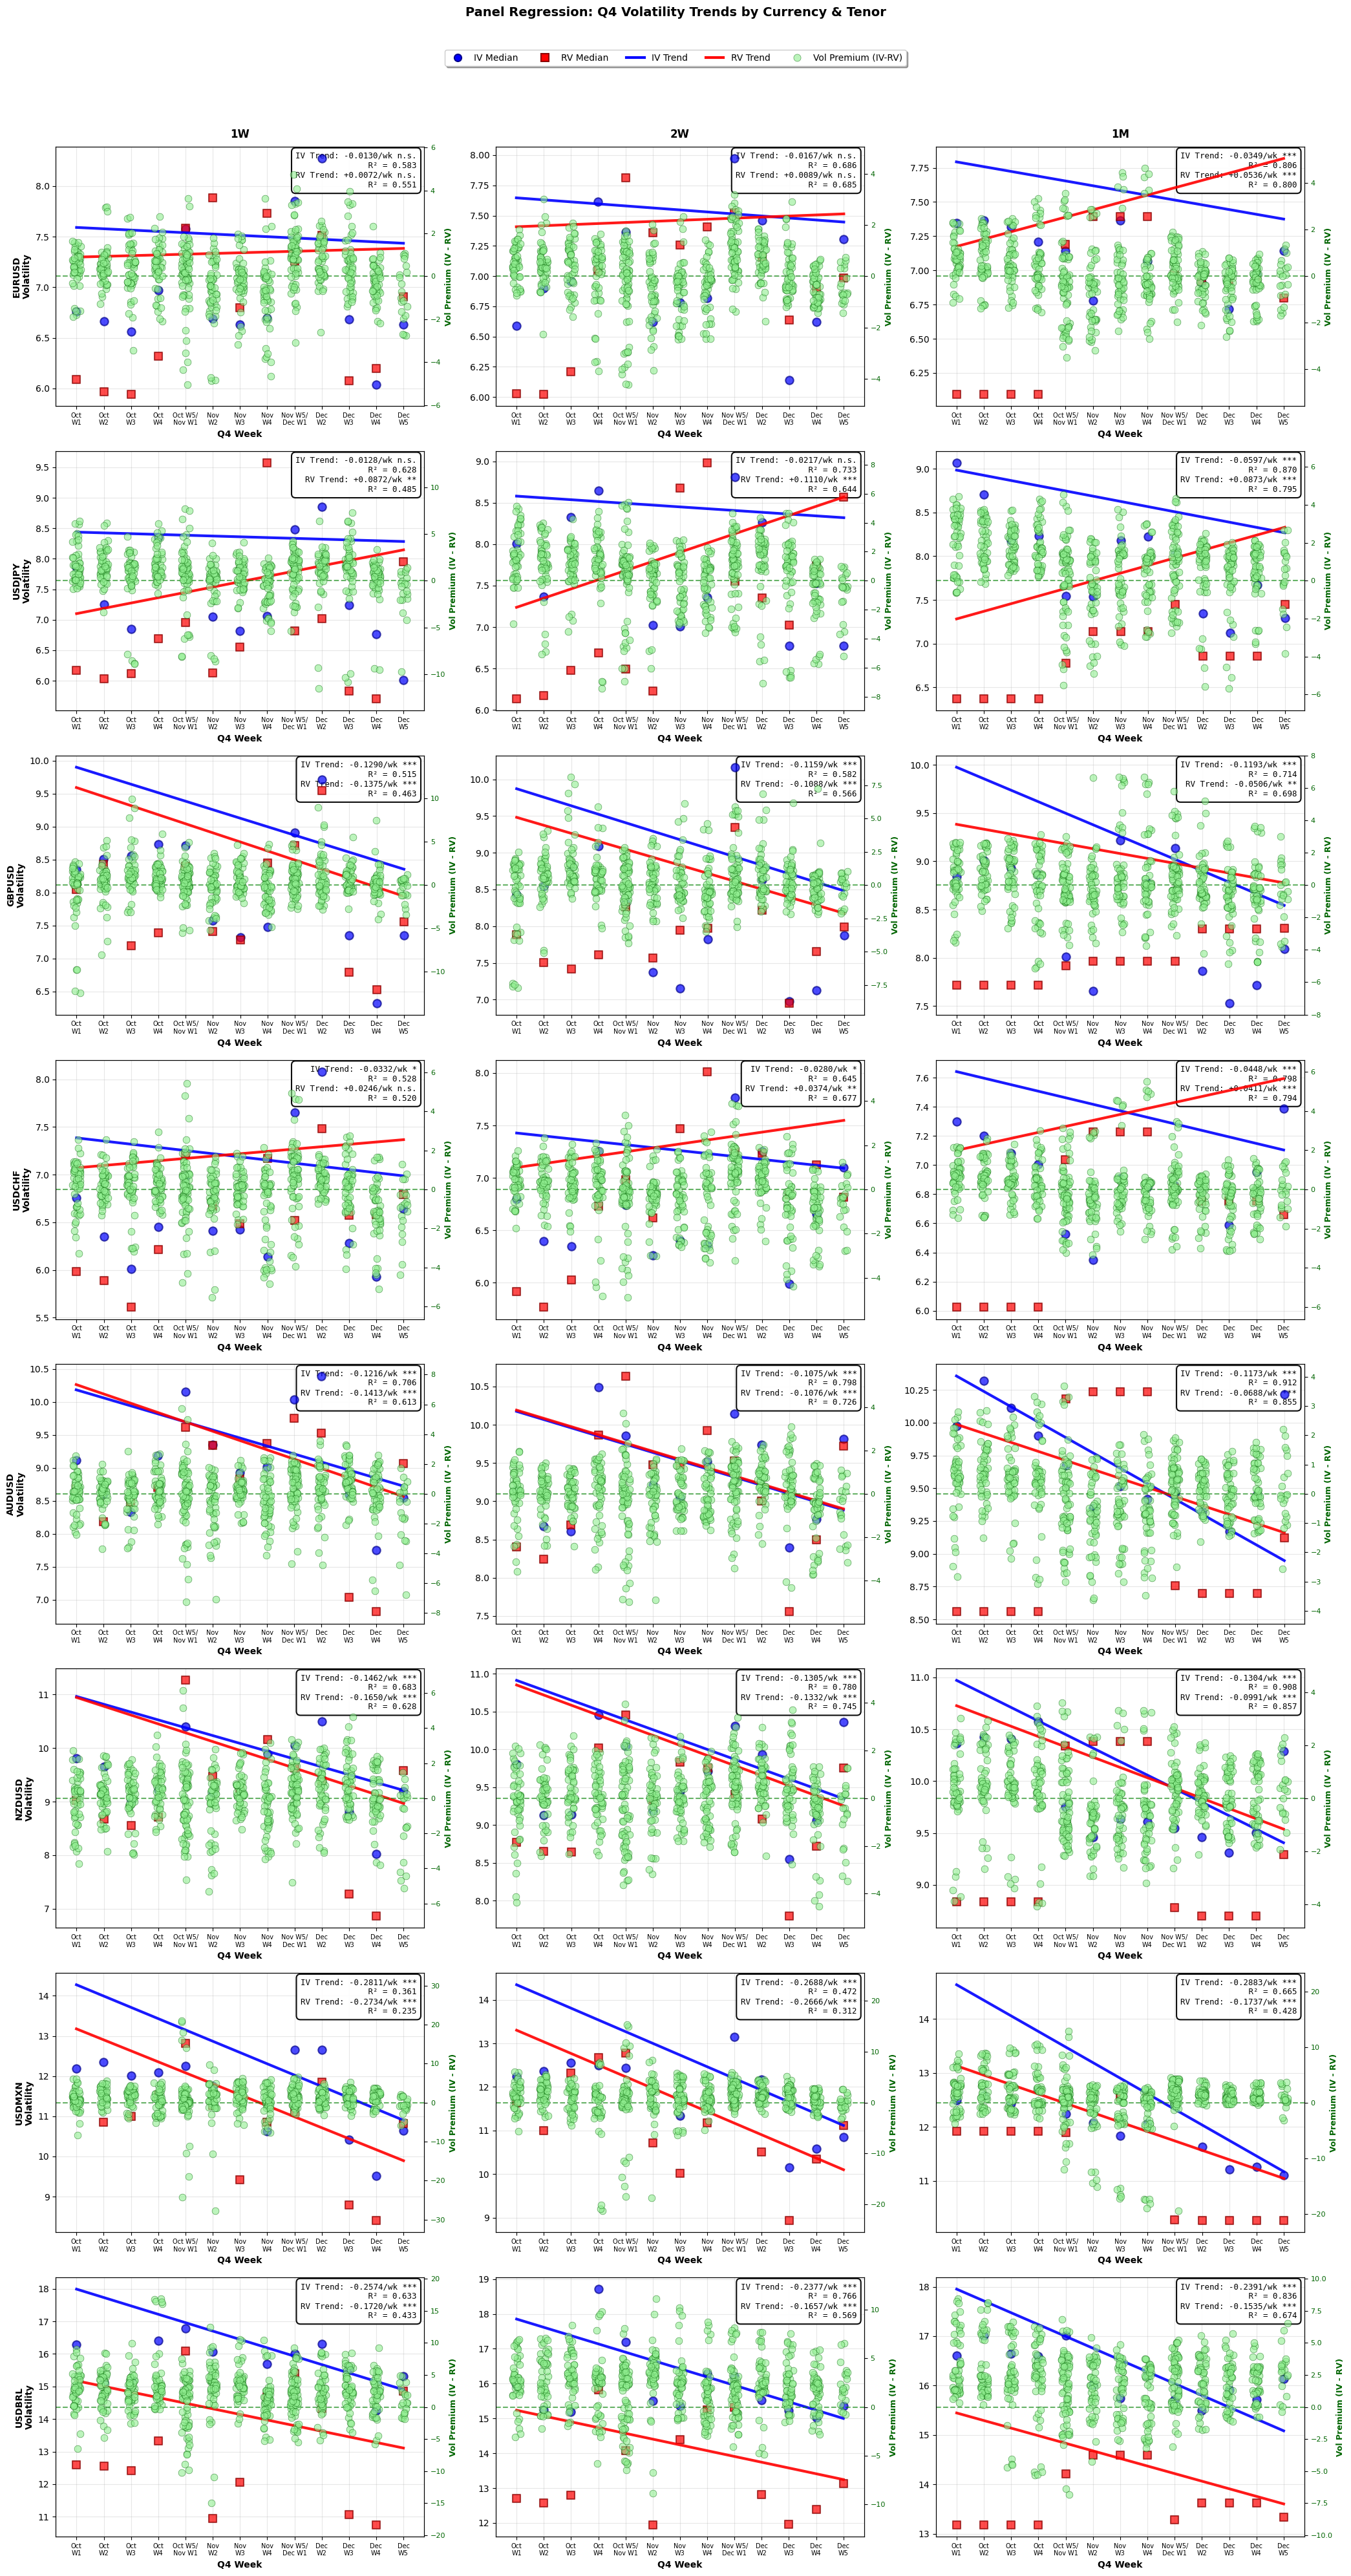

In [13]:
# Usage
panel_regression_with_plots(q4_data, ccys=['EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'AUDUSD', 'NZDUSD', 'USDMXN', 'USDBRL'], tenors=['1W', '2W', '1M'])

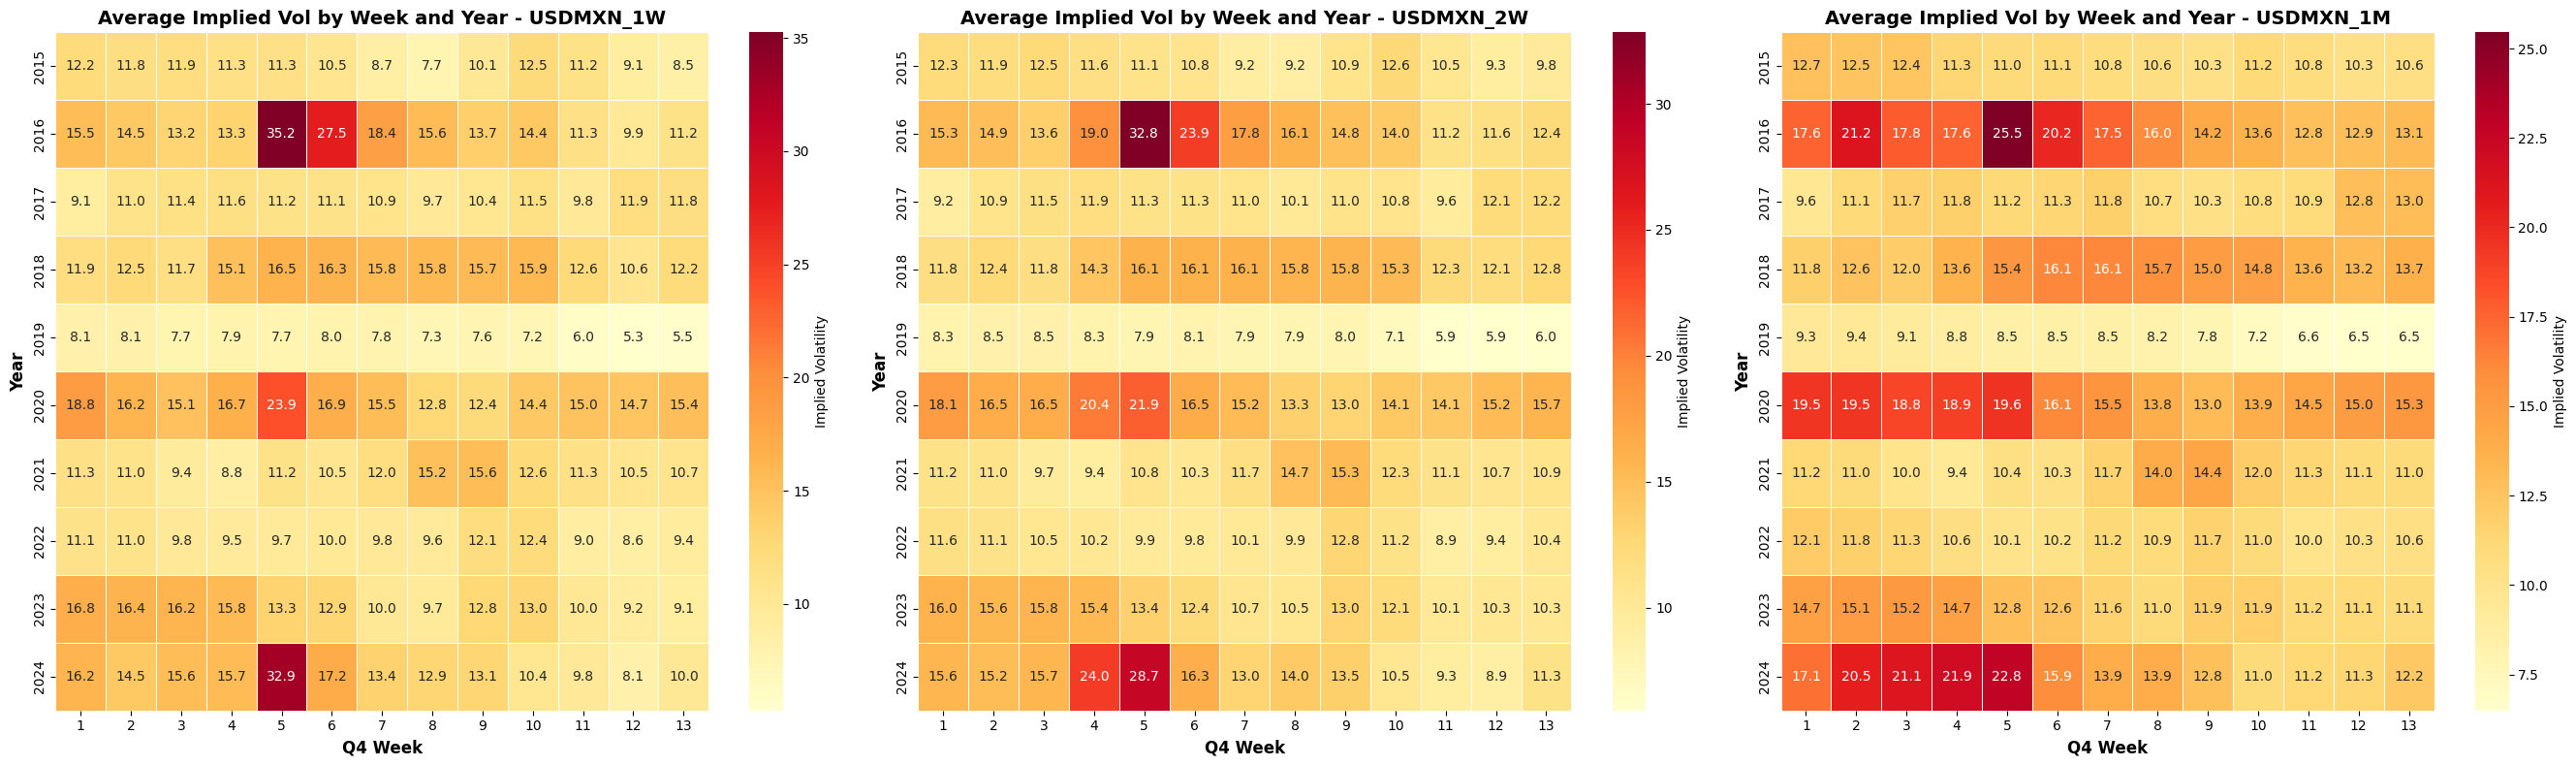

In [14]:
def plot_weekly_heatmap(data, ccy, tenors):
    fig, axes = plt.subplots(1, len(tenors), figsize=(9*len(tenors), 8))
    if len(tenors) == 1:
        axes = [axes]
    for idx, tenor_to_plot in enumerate(tenors):
        ax = axes[idx]
        iv_col = f'{ccy}_{tenor_to_plot}_IV'
        heatmap_data = data.pivot_table(
            values=iv_col,
            index='Year',
            columns='Q4_Week_Num',
            aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
                    cbar_kws={'label': 'Implied Volatility'}, ax=ax, linewidths=0.5)
        ax.set_xlabel('Q4 Week', fontsize=12, fontweight='bold')
        ax.set_ylabel('Year', fontsize=12, fontweight='bold')
        ax.set_title(f'Average Implied Vol by Week and Year - {ccy}_{tenor_to_plot}', 
                    fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_weekly_heatmap(q4_data, ccy='USDMXN', tenors=['1W', '2W', '1M'])

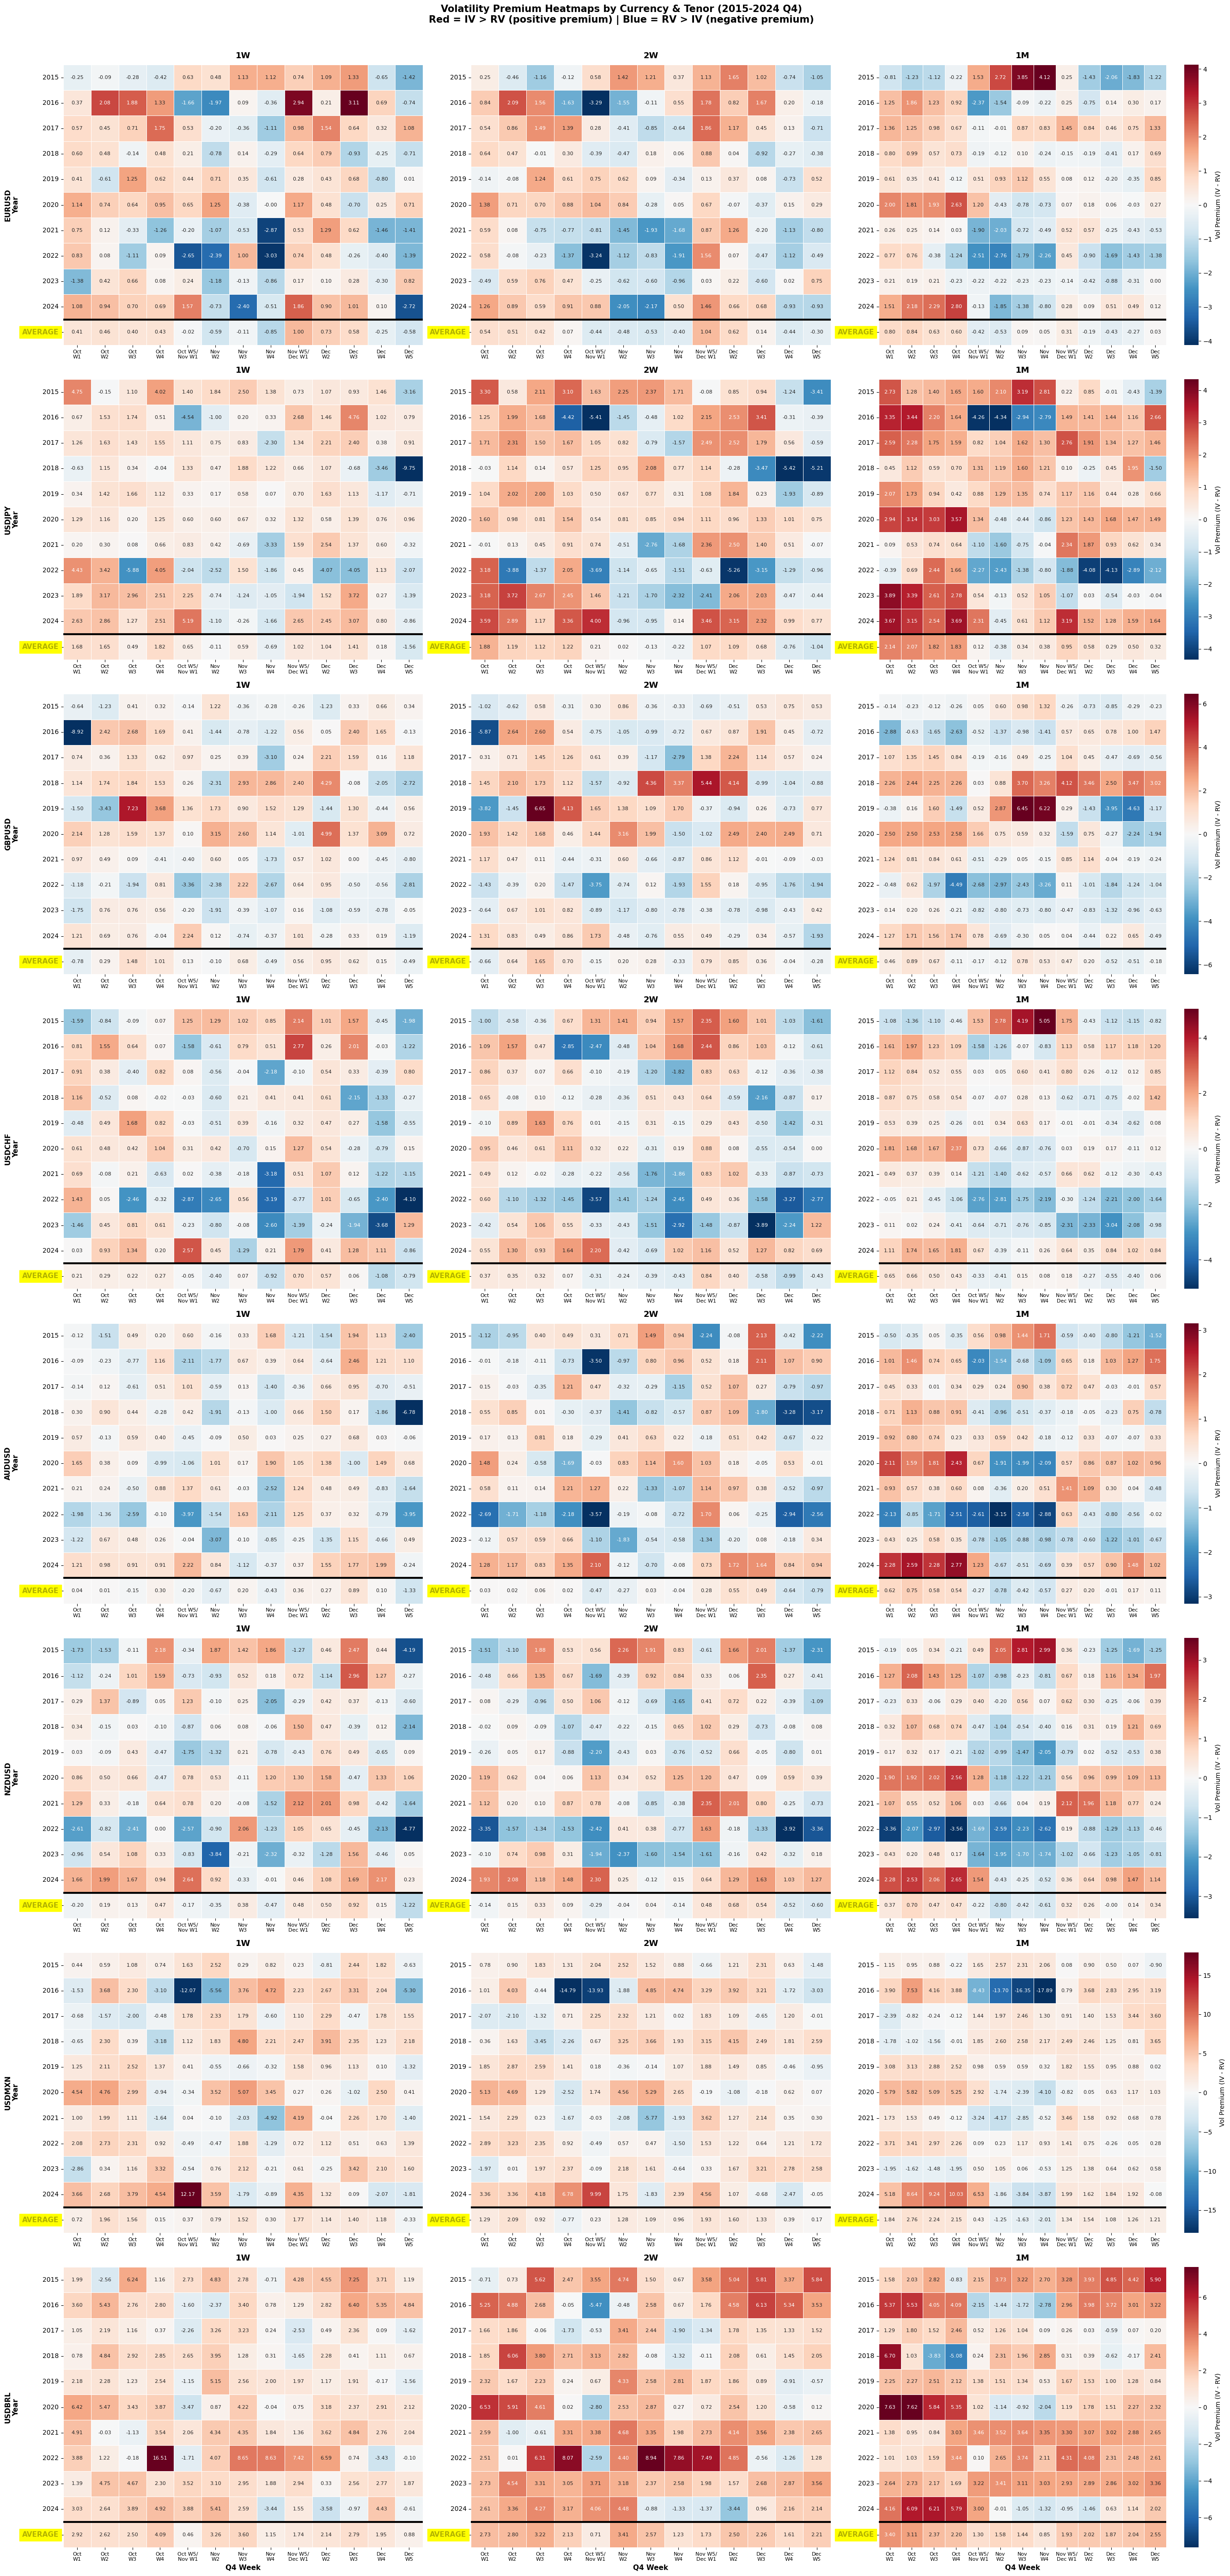

In [16]:
def plot_weekly_heatmap_premium_with_average(data, ccys, tenors):
    """
    Plot heatmaps for multiple currencies and tenors
    Rows = currencies, Columns = tenors
    """
    import numpy as np
    
    week_labels = {
        1: 'Oct\nW1', 2: 'Oct\nW2', 3: 'Oct\nW3', 4: 'Oct\nW4',
        5: 'Oct W5/\nNov W1', 6: 'Nov\nW2', 7: 'Nov\nW3', 8: 'Nov\nW4', 
        9: 'Nov W5/\nDec W1', 10: 'Dec\nW2', 11: 'Dec\nW3', 12: 'Dec\nW4', 
        13: 'Dec\nW5'}
    
    fig, axes = plt.subplots(len(ccys), len(tenors), 
                             figsize=(9*len(tenors), 7*len(ccys)))
    
    # Handle case of single ccy or single tenor
    if len(ccys) == 1 and len(tenors) == 1:
        axes = np.array([[axes]])
    elif len(ccys) == 1:
        axes = axes.reshape(1, -1)
    elif len(tenors) == 1:
        axes = axes.reshape(-1, 1)
    
    for ccy_idx, ccy in enumerate(ccys):
        for tenor_idx, tenor_to_plot in enumerate(tenors):
            ax = axes[ccy_idx, tenor_idx]
            
            premium_col = f'{ccy}_{tenor_to_plot}_premium'
            
            if premium_col not in data.columns:
                ax.text(0.5, 0.5, f'No data for\n{ccy} {tenor_to_plot}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='red')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Create pivot table
            heatmap_data = data.pivot_table(
                values=premium_col,
                index='Year',
                columns='Q4_Week_Num',
                aggfunc='mean')
            
            if heatmap_data.empty:
                ax.text(0.5, 0.5, f'No data for\n{ccy} {tenor_to_plot}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='orange')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Calculate weekly average across all years
            weekly_avg = heatmap_data.mean(axis=0)
            avg_row = pd.DataFrame(weekly_avg).T
            avg_row.index = ['AVERAGE']
            
            # Concatenate with main data
            heatmap_with_avg = pd.concat([heatmap_data, avg_row])
            
            # Calculate symmetric vmax for color scale
            vmax = max(abs(heatmap_data.min().min()), abs(heatmap_data.max().max()))
            
            # Create heatmap (only show colorbar on rightmost column)
            sns.heatmap(heatmap_with_avg, annot=True, fmt='.2f', 
                        cmap='RdBu_r',
                        center=0,
                        vmin=-vmax, vmax=vmax,
                        cbar_kws={'label': 'Vol Premium (IV - RV)'}, 
                        ax=ax, linewidths=0.5,
                        cbar=(tenor_idx == len(tenors)-1),  # Only rightmost column
                        annot_kws={'fontsize': 8})
            
            # Add thick line above AVERAGE row
            n_rows = len(heatmap_with_avg)
            n_cols = len(heatmap_with_avg.columns)
            ax.hlines(n_rows - 1, 0, n_cols, colors='black', linewidths=3)
            
            # Highlight AVERAGE row label
            ylabels = ax.get_yticklabels()
            if len(ylabels) > 0:
                ylabels[-1].set_weight('bold')
                ylabels[-1].set_fontsize(11)
                ylabels[-1].set_backgroundcolor('yellow')
                ylabels[-1].set_alpha(0.3)
            
            # ===================================================================
            # CUSTOM X-AXIS LABELS USING week_labels
            # ===================================================================
            
            # Get the actual week numbers from the columns
            week_numbers = heatmap_with_avg.columns.tolist()
            
            # Map week numbers to custom labels
            custom_xlabels = [week_labels.get(int(week), f'W{int(week)}') 
                             for week in week_numbers]
            
            # Set custom x-tick labels
            ax.set_xticklabels(custom_xlabels, rotation=0, fontsize=8)
            
            # ===================================================================
            # Labels
            # ===================================================================
            
            # X-axis label on bottom row only
            if ccy_idx == len(ccys) - 1:
                ax.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
            else:
                ax.set_xlabel('')
            
            # Y-axis label on leftmost column only
            if tenor_idx == 0:
                ax.set_ylabel(f'{ccy}\nYear', fontsize=11, fontweight='bold')
            else:
                ax.set_ylabel('')
            
            # Title on ALL subplots (showing tenor) - REMOVED CONDITIONAL
            ax.set_title(f'{tenor_to_plot}', fontsize=13, fontweight='bold', pad=10)
    
    # Add overall title
    fig.suptitle('Volatility Premium Heatmaps by Currency & Tenor (2015-2024 Q4)\nRed = IV > RV (positive premium) | Blue = RV > IV (negative premium)', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


plot_weekly_heatmap_premium_with_average(
    q4_data, 
    ccys=['EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'AUDUSD', 'NZDUSD', 'USDMXN', 'USDBRL'],
    tenors=['1W', '2W', '1M']
)

C:\Users\ntaylor\AppData\Local\Temp\ipykernel_15452\2745009576.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(monthly_data, labels=month_labels, patch_artist=True,
C:\Users\ntaylor\AppData\Local\Temp\ipykernel_15452\2745009576.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(period_data, labels=period_order, patch_artist=True,


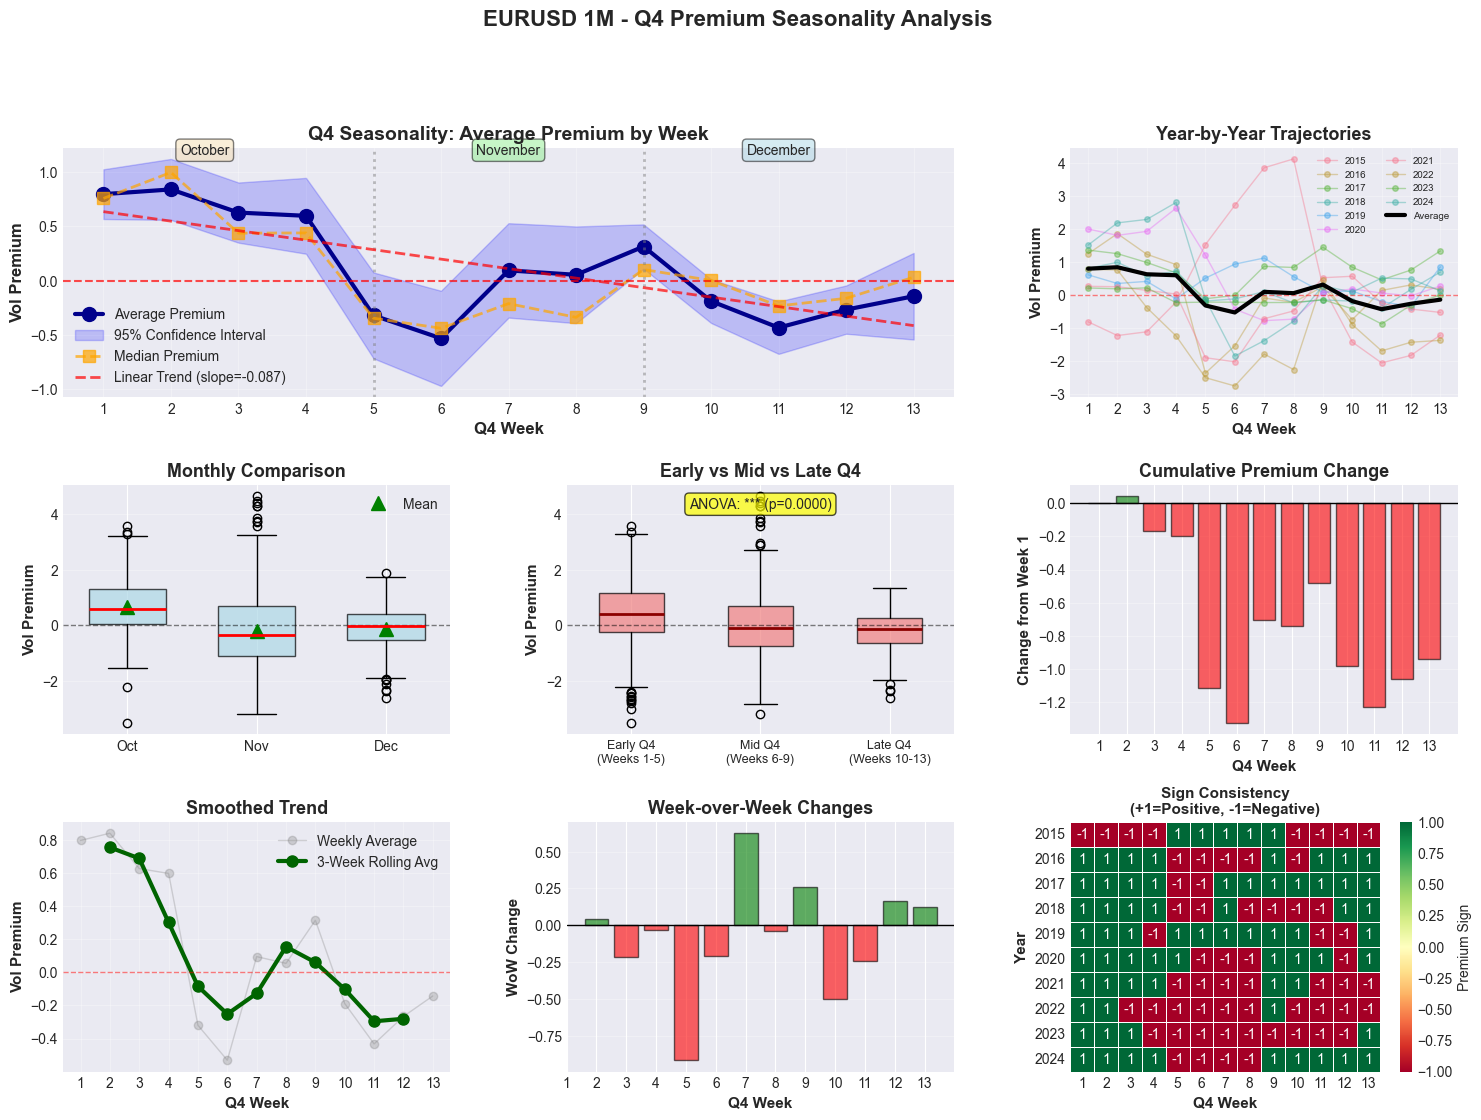


EURUSD 1M - SEASONALITY STATISTICS

LINEAR TREND TEST:
  Slope: -0.0874 (premium change per week)
  R²: 0.5079
  P-value: 0.0063
  ✓ SIGNIFICANT: Premium DECREASES through Q4
  Total Q4 change: -1.14 (Week 1 → Week 13)

MONTHLY COMPARISON:
  October: Mean=+0.673, Median=+0.576, N=220
  November: Mean=-0.201, Median=-0.337, N=216
  December: Mean=-0.135, Median=-0.020, N=220

  ANOVA F-statistic: 35.0317, P-value: 0.0000
  ✓ SIGNIFICANT differences between months

EARLY vs LATE Q4:
  Early Q4 (Weeks 1-5): Mean=+0.447, N=270
  Late Q4 (Weeks 10-13): Mean=-0.278, N=170
  Difference: -0.724

  T-test: t=6.4506, p=0.0000
  ✓ SIGNIFICANT difference between Early and Late Q4

YEAR-OVER-YEAR CONSISTENCY:
  2015: ↘ slope=-0.0768
  2016: ↘ slope=-0.0939
  2017: ↘ slope=-0.0015
  2018: ↘ slope=-0.0629
  2019: ↘ slope=-0.0275
  2020: ↘ slope=-0.2028
  2021: ↘ slope=-0.0091
  2022: ↘ slope=-0.1190
  2023: ↘ slope=-0.0469
  2024: ↘ slope=-0.1659

  Consistency: 10 years declining, 0 years rising
  

In [201]:
def analyze_premium_seasonality(data, ccy, tenor):
    """
    Comprehensive analysis of Q4 seasonality in vol premium
    
    Parameters:
    -----------
    data : pd.DataFrame
        The aligned volatility data
    ccy : str
        Currency pair (e.g., 'EURUSD')
    tenor : str
        Tenor to analyze (e.g., '1M')
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from scipy import stats
    
    premium_col = f'{ccy}_{tenor}_premium'
    
    if premium_col not in data.columns:
        print(f"Error: {premium_col} not found")
        return
    
    # Prepare data
    data_subset = data[['Q4_Week_Num', 'Month', 'Year', premium_col]].dropna()
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ===================================================================
    # 1. AVERAGE PREMIUM BY WEEK (Main seasonality plot)
    # ===================================================================
    ax1 = fig.add_subplot(gs[0, :2])
    
    # Calculate weekly statistics
    weekly_stats = data_subset.groupby('Q4_Week_Num')[premium_col].agg([
        'mean', 'median', 'std', 'count',
        ('sem', lambda x: x.std() / np.sqrt(len(x)))  # Standard error
    ])
    
    weeks = weekly_stats.index
    means = weekly_stats['mean']
    sems = weekly_stats['sem']
    
    # Plot mean with confidence interval
    ax1.plot(weeks, means, 'o-', linewidth=3, markersize=10, 
            color='darkblue', label='Average Premium')
    ax1.fill_between(weeks, means - 1.96*sems, means + 1.96*sems, 
                     alpha=0.2, color='blue', label='95% Confidence Interval')
    
    # Add median line
    ax1.plot(weeks, weekly_stats['median'], 's--', linewidth=2, markersize=8,
            color='orange', alpha=0.7, label='Median Premium')
    
    # Zero line
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Month boundaries (approximate)
    ax1.axvline(x=5, color='gray', linestyle=':', alpha=0.5, linewidth=2)
    ax1.axvline(x=9, color='gray', linestyle=':', alpha=0.5, linewidth=2)
    ax1.text(2.5, ax1.get_ylim()[1]*0.95, 'October', ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax1.text(7, ax1.get_ylim()[1]*0.95, 'November', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax1.text(11, ax1.get_ylim()[1]*0.95, 'December', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    # Trend line
    from numpy.polynomial import Polynomial
    p = Polynomial.fit(weeks, means, 1)
    trend = p(weeks)
    slope = p.convert().coef[1]
    ax1.plot(weeks, trend, 'r--', linewidth=2, alpha=0.7,
            label=f'Linear Trend (slope={slope:.3f})')
    
    ax1.set_xlabel('Q4 Week', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Vol Premium', fontsize=12, fontweight='bold')
    ax1.set_title('Q4 Seasonality: Average Premium by Week', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(range(1, 14))
    
    # ===================================================================
    # 2. INDIVIDUAL YEAR TRAJECTORIES
    # ===================================================================
    ax2 = fig.add_subplot(gs[0, 2])
    
    # Plot each year separately
    for year in sorted(data_subset['Year'].unique()):
        year_data = data_subset[data_subset['Year'] == year]
        year_weekly = year_data.groupby('Q4_Week_Num')[premium_col].mean()
        
        ax2.plot(year_weekly.index, year_weekly.values, 'o-', 
                alpha=0.4, linewidth=1, markersize=4, label=str(year))
    
    # Overlay average
    ax2.plot(weeks, means, 'k-', linewidth=3, markersize=0, 
            label='Average', zorder=10)
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    ax2.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Vol Premium', fontsize=11, fontweight='bold')
    ax2.set_title('Year-by-Year Trajectories', fontsize=13, fontweight='bold')
    ax2.legend(loc='best', fontsize=7, ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(1, 14))
    
    # ===================================================================
    # 3. MONTHLY COMPARISON (Oct vs Nov vs Dec)
    # ===================================================================
    ax3 = fig.add_subplot(gs[1, 0])
    
    # Group by month
    monthly_data = []
    month_labels = []
    for month in [10, 11, 12]:
        month_premiums = data_subset[data_subset['Month'] == month][premium_col]
        if len(month_premiums) > 0:
            monthly_data.append(month_premiums)
            month_labels.append(['Oct', 'Nov', 'Dec'][month-10])
    
    bp = ax3.boxplot(monthly_data, labels=month_labels, patch_artist=True,
                     widths=0.6, showfliers=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax3.set_ylabel('Vol Premium', fontsize=11, fontweight='bold')
    ax3.set_title('Monthly Comparison', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add mean markers
    for i, data_month in enumerate(monthly_data):
        mean_val = data_month.mean()
        ax3.plot(i+1, mean_val, 'g^', markersize=10, label='Mean' if i == 0 else '')
    ax3.legend()
    
    # ===================================================================
    # 4. EARLY vs MID vs LATE Q4
    # ===================================================================
    ax4 = fig.add_subplot(gs[1, 1])
    
    # Define periods
    data_subset['Period'] = data_subset['Q4_Week_Num'].map(
        lambda x: 'Early Q4\n(Weeks 1-5)' if x <= 5 
        else 'Mid Q4\n(Weeks 6-9)' if x <= 9 
        else 'Late Q4\n(Weeks 10-13)')
    
    period_order = ['Early Q4\n(Weeks 1-5)', 'Mid Q4\n(Weeks 6-9)', 'Late Q4\n(Weeks 10-13)']
    period_data = [data_subset[data_subset['Period'] == p][premium_col] for p in period_order]
    
    bp = ax4.boxplot(period_data, labels=period_order, patch_artist=True,
                     widths=0.5, showfliers=True,
                     boxprops=dict(facecolor='lightcoral', alpha=0.7),
                     medianprops=dict(color='darkred', linewidth=2))
    
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_ylabel('Vol Premium', fontsize=11, fontweight='bold')
    ax4.set_title('Early vs Mid vs Late Q4', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.tick_params(axis='x', labelsize=9)
    
    # Add statistical test
    from scipy.stats import f_oneway
    f_stat, p_val = f_oneway(*period_data)
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    ax4.text(0.5, 0.95, f'ANOVA: {sig_text} (p={p_val:.4f})', 
            transform=ax4.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # ===================================================================
    # 5. CUMULATIVE CHANGE THROUGH Q4
    # ===================================================================
    ax5 = fig.add_subplot(gs[1, 2])
    
    # Calculate cumulative change from Week 1
    baseline = means.iloc[0]
    cumulative_change = means - baseline
    
    ax5.bar(weeks, cumulative_change, color=['red' if x < 0 else 'green' for x in cumulative_change],
           alpha=0.6, edgecolor='black')
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    ax5.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Change from Week 1', fontsize=11, fontweight='bold')
    ax5.set_title('Cumulative Premium Change', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_xticks(range(1, 14))
    
    # ===================================================================
    # 6. ROLLING AVERAGE (Smoothed Trend)
    # ===================================================================
    ax6 = fig.add_subplot(gs[2, 0])
    
    # Calculate 3-week rolling average
    rolling_mean = weekly_stats['mean'].rolling(window=3, center=True).mean()
    
    ax6.plot(weeks, means, 'o-', alpha=0.3, color='gray', 
            linewidth=1, markersize=6, label='Weekly Average')
    ax6.plot(weeks, rolling_mean, 'o-', linewidth=3, markersize=8,
            color='darkgreen', label='3-Week Rolling Avg')
    ax6.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    ax6.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Vol Premium', fontsize=11, fontweight='bold')
    ax6.set_title('Smoothed Trend', fontsize=13, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    ax6.set_xticks(range(1, 14))
    
    # ===================================================================
    # 7. WEEK-OVER-WEEK CHANGES
    # ===================================================================
    ax7 = fig.add_subplot(gs[2, 1])
    
    # Calculate week-over-week changes
    wow_changes = means.diff()
    
    colors = ['red' if x < 0 else 'green' for x in wow_changes]
    ax7.bar(weeks[1:], wow_changes[1:], color=colors[1:], alpha=0.6, edgecolor='black')
    ax7.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    ax7.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
    ax7.set_ylabel('WoW Change', fontsize=11, fontweight='bold')
    ax7.set_title('Week-over-Week Changes', fontsize=13, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    ax7.set_xticks(range(1, 14))
    
    # ===================================================================
    # 8. CONSISTENCY HEATMAP
    # ===================================================================
    ax8 = fig.add_subplot(gs[2, 2])
    
    # Calculate direction (positive/negative) by year and week
    direction_pivot = data_subset.pivot_table(
        values=premium_col,
        index='Year',
        columns='Q4_Week_Num',
        aggfunc=lambda x: 1 if x.mean() > 0 else -1
    )
    
    sns.heatmap(direction_pivot, cmap='RdYlGn', center=0, 
               cbar_kws={'label': 'Premium Sign'}, ax=ax8,
               linewidths=0.5, annot=True, fmt='d',
               vmin=-1, vmax=1)
    
    ax8.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
    ax8.set_ylabel('Year', fontsize=11, fontweight='bold')
    ax8.set_title('Sign Consistency\n(+1=Positive, -1=Negative)', fontsize=11, fontweight='bold')
    
    # Overall title
    fig.suptitle(f'{ccy} {tenor} - Q4 Premium Seasonality Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()
    
    # ===================================================================
    # STATISTICAL ANALYSIS
    # ===================================================================
    print("\n" + "="*80)
    print(f"{ccy} {tenor} - SEASONALITY STATISTICS")
    print("="*80)
    
    # Linear trend test
    slope, intercept, r_value, p_value, std_err = stats.linregress(weeks, means)
    print(f"\nLINEAR TREND TEST:")
    print(f"  Slope: {slope:.4f} (premium change per week)")
    print(f"  R²: {r_value**2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        direction = "DECREASES" if slope < 0 else "INCREASES"
        print(f"  ✓ SIGNIFICANT: Premium {direction} through Q4")
        print(f"  Total Q4 change: {slope * 13:.2f} (Week 1 → Week 13)")
    else:
        print(f"  ✗ No significant linear trend")
    
    # Monthly comparison
    print(f"\nMONTHLY COMPARISON:")
    for i, month in enumerate([10, 11, 12]):
        month_name = ['October', 'November', 'December'][i]
        month_data = data_subset[data_subset['Month'] == month][premium_col]
        print(f"  {month_name}: Mean={month_data.mean():+.3f}, "
              f"Median={month_data.median():+.3f}, N={len(month_data)}")
    
    # ANOVA test
    oct_data = data_subset[data_subset['Month'] == 10][premium_col]
    nov_data = data_subset[data_subset['Month'] == 11][premium_col]
    dec_data = data_subset[data_subset['Month'] == 12][premium_col]
    f_stat, p_val = f_oneway(oct_data, nov_data, dec_data)
    print(f"\n  ANOVA F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"  ✓ SIGNIFICANT differences between months")
    else:
        print(f"  ✗ No significant differences between months")
    
    # Early vs Late Q4
    print(f"\nEARLY vs LATE Q4:")
    early = data_subset[data_subset['Q4_Week_Num'] <= 5][premium_col]
    late = data_subset[data_subset['Q4_Week_Num'] >= 10][premium_col]
    
    print(f"  Early Q4 (Weeks 1-5): Mean={early.mean():+.3f}, N={len(early)}")
    print(f"  Late Q4 (Weeks 10-13): Mean={late.mean():+.3f}, N={len(late)}")
    print(f"  Difference: {late.mean() - early.mean():+.3f}")
    
    # T-test
    t_stat, p_val = stats.ttest_ind(early, late)
    print(f"\n  T-test: t={t_stat:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  ✓ SIGNIFICANT difference between Early and Late Q4")
    else:
        print(f"  ✗ No significant difference")
    
    # Year-over-year consistency
    print(f"\nYEAR-OVER-YEAR CONSISTENCY:")
    yearly_slopes = []
    for year in sorted(data_subset['Year'].unique()):
        year_data = data_subset[data_subset['Year'] == year]
        year_weekly = year_data.groupby('Q4_Week_Num')[premium_col].mean()
        if len(year_weekly) >= 5:
            slope_y, _, _, _, _ = stats.linregress(year_weekly.index, year_weekly.values)
            yearly_slopes.append(slope_y)
            direction = "↘" if slope_y < 0 else "↗"
            print(f"  {year}: {direction} slope={slope_y:+.4f}")
    
    if yearly_slopes:
        n_negative = sum(1 for s in yearly_slopes if s < 0)
        n_positive = sum(1 for s in yearly_slopes if s > 0)
        print(f"\n  Consistency: {n_negative} years declining, {n_positive} years rising")
        consistency_pct = max(n_negative, n_positive) / len(yearly_slopes) * 100
        print(f"  Consistency rate: {consistency_pct:.1f}%")

# Usage
analyze_premium_seasonality(q4_data, ccy='EURUSD', tenor='1M')

In [ ]:
def regime_specific_regression(data, ccy, tenors):
    """
    Run separate regressions for high vol vs low vol periods
    """
    from scipy.stats import linregress
    
    print("\n" + "="*80)
    print("REGIME-SPECIFIC REGRESSION")
    print("="*80)
    
    for tenor in tenors:
        iv_col = f'{ccy}_{tenor}_IV'
        
        # Define regimes based on median IV
        median_iv = data[iv_col].median()
        high_vol = data[data[iv_col] > median_iv]
        low_vol = data[data[iv_col] <= median_iv]
        
        print(f"\n{tenor} (median IV = {median_iv:.2f}):")
        
        # High vol regime
        high_weekly = high_vol.groupby('Q4_Week_Num')[iv_col].mean()
        if len(high_weekly) >= 5:
            slope_high, _, r_high, p_high, _ = linregress(
                high_weekly.index.values, high_weekly.values
            )
            print(f"\n  HIGH VOL REGIME (IV > {median_iv:.2f}):")
            print(f"    Slope: {slope_high:.4f}")
            print(f"    R²: {r_high**2:.4f}")
            print(f"    P-value: {p_high:.4f}")
            print(f"    Observations: {len(high_vol)}")
        
        # Low vol regime  
        low_weekly = low_vol.groupby('Q4_Week_Num')[iv_col].mean()
        if len(low_weekly) >= 5:
            slope_low, _, r_low, p_low, _ = linregress(
                low_weekly.index.values, low_weekly.values
            )
            print(f"\n  LOW VOL REGIME (IV ≤ {median_iv:.2f}):")
            print(f"    Slope: {slope_low:.4f}")
            print(f"    R²: {r_low**2:.4f}")
            print(f"    P-value: {p_low:.4f}")
            print(f"    Observations: {len(low_vol)}")
        
        # Compare
        if 'slope_high' in locals() and 'slope_low' in locals():
            if np.sign(slope_high) != np.sign(slope_low):
                print(f"\n  ⚠ WARNING: Opposite trends in different regimes!")
                print(f"    High vol: {'↘' if slope_high < 0 else '↗'}")
                print(f"    Low vol: {'↘' if slope_low < 0 else '↗'}")

# Usage
regime_specific_regression(q4_data, ccy='EURUSD', tenors=['1W', '2W', '1M'])

In [ ]:
# =====================================================================================
# Regression Analysis
# =====================================================================================
def plot_weeklyMeanRegression(data, ccy, tenors):
    from scipy.stats import linregress
    fig, axes = plt.subplots(1, len(tenors), figsize=(9*len(tenors), 6))
    if len(tenors) == 1:
        axes = [axes]
    print("\nQ4 TREND ANALYSIS (Linear Regression):")
    print("=" * 60)
    week_labels = {
        1: 'Oct\nW1', 
        2: 'Oct\nW2', 
        3: 'Oct\nW3', 
        4: 'Oct\nW4',
        5: 'Oct W5/\nNov W1',  # Oct 29-31, Nov 1-7
        6: 'Nov\nW2', 
        7: 'Nov\nW3', 
        8: 'Nov\nW4', 
        9: 'Nov W5/\nDec W1',  # Nov 29-30, Dec 1-7
        10: 'Dec\nW2', 
        11: 'Dec\nW3', 
        12: 'Dec\nW4', 
        13: 'Dec\nW5'}
    for idx, tenor in enumerate(tenors):
        ax = axes[idx]
        iv_col = f'{ccy}_{tenor}_IV'
        rv_col = f'{ccy}_{tenor}_RV_forward'
        if iv_col in data.columns and rv_col in data.columns:
            weekly_avg_iv = data.groupby('Q4_Week_Num')[iv_col].mean()
            weekly_avg_rv = data.groupby('Q4_Week_Num')[rv_col].mean()
            weeks = weekly_avg_iv.index.values
            ivs = weekly_avg_iv.values
            rvs = weekly_avg_rv.values
            slope_iv, intercept_iv, r_value_iv, p_value_iv, std_err_iv = linregress(weeks, ivs)
            slope_rv, intercept_rv, r_value_rv, p_value_rv, std_err_rv = linregress(weeks, rvs)
            print(f"\n{tenor}:")
            print(f"  IMPLIED VOL:")
            print(f"    Slope: {slope_iv:.4f} (vol change per week)")
            print(f"    R-squared: {r_value_iv**2:.4f}")
            print(f"    P-value: {p_value_iv:.4f}")
            if p_value_iv < 0.05:
                if slope_iv > 0:
                    print(f"    ✓ SIGNIFICANT UPWARD TREND")
                else:
                    print(f"    ✓ SIGNIFICANT DOWNWARD TREND")
            else:
                print(f"    ✗ No significant trend")
            
            print(f"  REALIZED VOL (FORWARD):")
            print(f"    Slope: {slope_rv:.4f} (vol change per week)")
            print(f"    R-squared: {r_value_rv**2:.4f}")
            print(f"    P-value: {p_value_rv:.4f}")
            if p_value_rv < 0.05:
                if slope_rv > 0:
                    print(f"    ✓ SIGNIFICANT UPWARD TREND")
                else:
                    print(f"    ✓ SIGNIFICANT DOWNWARD TREND")
            else:
                print(f"    ✗ No significant trend")
            
            # Plot IV data
            ax.scatter(weeks, ivs, s=120, alpha=0.7, label='IV Weekly Average', 
                      color='blue', marker='o', edgecolors='darkblue', linewidth=1.5)
            
            # Plot RV data
            ax.scatter(weeks, rvs, s=120, alpha=0.7, label='RV Weekly Average', 
                      color='coral', marker='s', edgecolors='darkred', linewidth=1.5)
            
            # Add all individual IV points
            all_data_iv = data[['Q4_Week_Num', iv_col]].dropna()
            ax.scatter(all_data_iv['Q4_Week_Num'], all_data_iv[iv_col], 
                      s=15, alpha=0.15, color='blue', label='IV Daily Data')
            
            # Add all individual RV points
            all_data_rv = data[['Q4_Week_Num', rv_col]].dropna()
            ax.scatter(all_data_rv['Q4_Week_Num'], all_data_rv[rv_col], 
                      s=15, alpha=0.15, color='coral', label='RV Daily Data')
            
            # IV Regression line
            x_fit = np.linspace(weeks.min(), weeks.max(), 100)
            y_fit_iv = slope_iv * x_fit + intercept_iv
            ax.plot(x_fit, y_fit_iv, 'b-', linewidth=2.5, 
                   label=f'IV Trend: y={slope_iv:.3f}x+{intercept_iv:.2f}', alpha=0.8)
            
            # RV Regression line
            y_fit_rv = slope_rv * x_fit + intercept_rv
            ax.plot(x_fit, y_fit_rv, 'r-', linewidth=2.5, 
                   label=f'RV Trend: y={slope_rv:.3f}x+{intercept_rv:.2f}', alpha=0.8)
            
            # Add text with trend direction for both
            trend_text_iv = "↗" if slope_iv > 0 else "↘"
            trend_text_rv = "↗" if slope_rv > 0 else "↘"
            
            ax.text(0.02, 0.98, f'IV: {trend_text_iv} {"Rising" if slope_iv > 0 else "Falling"}', 
                   transform=ax.transAxes, 
                   fontsize=12, fontweight='bold', va='top',
                   color='blue',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
            
            ax.text(0.02, 0.90, f'RV: {trend_text_rv} {"Rising" if slope_rv > 0 else "Falling"}', 
                   transform=ax.transAxes, 
                   fontsize=12, fontweight='bold', va='top',
                   color='red',
                   bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
            
            ax.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
            ax.set_ylabel('Volatility', fontsize=11, fontweight='bold')
            ax.set_title(f'{tenor} - Vol Trend Through Q4', 
                        fontsize=13, fontweight='bold')
            ax.legend(loc='best', fontsize=9)
            ax.grid(True, alpha=0.3)
            
            # Set custom x-axis labels
            ax.set_xticks(range(1, 14))
            ax.set_xticklabels([week_labels.get(i, f'W{i}') for i in range(1, 14)], 
                              fontsize=8)
    
    plt.tight_layout()
    plt.show()


def daily_regression_with_plots_allDataTogether(data, ccy, tenors):
    from scipy.stats import linregress, t
    import matplotlib.pyplot as plt
    import numpy as np
    week_labels = {
        1: 'Oct\nW1', 2: 'Oct\nW2', 3: 'Oct\nW3', 4: 'Oct\nW4',
        5: 'Oct W5/\nNov W1', 6: 'Nov\nW2', 7: 'Nov\nW3', 8: 'Nov\nW4', 
        9: 'Nov W5/\nDec W1', 10: 'Dec\nW2', 11: 'Dec\nW3', 12: 'Dec\nW4', 
        13: 'Dec\nW5'}
    fig, axes = plt.subplots(1, len(tenors), figsize=(9*len(tenors), 6))
    if len(tenors) == 1:
        axes = [axes]
    for idx, tenor in enumerate(tenors):
        ax = axes[idx]
        iv_col = f'{ccy}_{tenor}_IV'
        rv_col = f'{ccy}_{tenor}_RV_forward'
        daily_data = data[['Q4_Week_Num', iv_col, rv_col]].dropna()
        weeks_daily = daily_data['Q4_Week_Num'].values
        ivs_daily = daily_data[iv_col].values
        rvs_daily = daily_data[rv_col].values
        n_obs = len(weeks_daily)
        # =============REGRESSION FOR IMPLIED VOL=============
        slope_iv, intercept_iv, r_value_iv, p_value_iv, std_err_iv = linregress(weeks_daily, ivs_daily)
        dof_iv = n_obs - 2
        t_val_iv = t.ppf(0.975, dof_iv)
        ci_lower_iv = slope_iv - t_val_iv * std_err_iv
        ci_upper_iv = slope_iv + t_val_iv * std_err_iv
        print(f"\n{tenor} - IMPLIED VOL:")
        print(f"  Sample size: {n_obs} daily observations")
        print(f"  Slope: {slope_iv:.4f} ± {std_err_iv:.4f} (standard error)")
        print(f"  95% CI: [{ci_lower_iv:.4f}, {ci_upper_iv:.4f}]")
        print(f"  R²: {r_value_iv**2:.4f}")
        print(f"  P-value: {p_value_iv:.6f}")
        if p_value_iv < 0.05:
            if slope_iv > 0:
                print(f"  ✓ SIGNIFICANT UPWARD TREND")
            else:
                print(f"  ✓ SIGNIFICANT DOWNWARD TREND")
            print(f"  Total Q4 change: {slope_iv * 13:.2f}% (Week 1 → Week 13)")
        else:
            print(f"  ✗ No significant trend")
        # =============REGRESSION FOR REALIZED VOL=============
        slope_rv, intercept_rv, r_value_rv, p_value_rv, std_err_rv = linregress(weeks_daily, rvs_daily)
        dof_rv = n_obs - 2
        t_val_rv = t.ppf(0.975, dof_rv)
        ci_lower_rv = slope_rv - t_val_rv * std_err_rv
        ci_upper_rv = slope_rv + t_val_rv * std_err_rv
        print(f"\n{tenor} - REALIZED VOL:")
        print(f"  Sample size: {n_obs} daily observations")
        print(f"  Slope: {slope_rv:.4f} ± {std_err_rv:.4f}")
        print(f"  95% CI: [{ci_lower_rv:.4f}, {ci_upper_rv:.4f}]")
        print(f"  R²: {r_value_rv**2:.4f}")
        print(f"  P-value: {p_value_rv:.6f}")
        if p_value_rv < 0.05:
            if slope_rv > 0:
                print(f"  ✓ SIGNIFICANT UPWARD TREND")
            else:
                print(f"  ✓ SIGNIFICANT DOWNWARD TREND")
            print(f"  Total Q4 change: {slope_rv * 13:.2f}%")
        else:
            print(f"  ✗ No significant trend")
        # =============PLOTTING=============
        ax.scatter(weeks_daily, ivs_daily, s=8, alpha=0.15, color='blue', 
                  label=f'IV Daily Data (n={n_obs})')
        ax.scatter(weeks_daily, rvs_daily, s=8, alpha=0.15, color='coral', 
                  label=f'RV Daily Data (n={n_obs})')
        weekly_avg_iv = data.groupby('Q4_Week_Num')[iv_col].mean()
        weekly_avg_rv = data.groupby('Q4_Week_Num')[rv_col].mean()
        ax.scatter(weekly_avg_iv.index, weekly_avg_iv.values, s=120, alpha=0.8, 
                  color='blue', marker='o', edgecolors='darkblue', linewidth=2,
                  label='IV Weekly Average', zorder=5)
        ax.scatter(weekly_avg_rv.index, weekly_avg_rv.values, s=120, alpha=0.8, 
                  color='coral', marker='s', edgecolors='darkred', linewidth=2,
                  label='RV Weekly Average', zorder=5)
        x_fit = np.linspace(weeks_daily.min(), weeks_daily.max(), 100)
        y_fit_iv = slope_iv * x_fit + intercept_iv
        y_fit_rv = slope_rv * x_fit + intercept_rv
        ax.plot(x_fit, y_fit_iv, 'b-', linewidth=3, alpha=0.8,
               label=f'IV Trend: {slope_iv:.4f}x + {intercept_iv:.2f}')
        ax.plot(x_fit, y_fit_rv, 'r-', linewidth=3, alpha=0.8,
               label=f'RV Trend: {slope_rv:.4f}x + {intercept_rv:.2f}')
        # Add confidence bands (optional - makes plot busier)
        # Uncomment if you want to see uncertainty bands
        # y_err_iv = t_val_iv * std_err_iv * np.sqrt(1 + 1/n_obs + (x_fit - weeks_daily.mean())**2 / np.sum((weeks_daily - weeks_daily.mean())**2))
        # ax.fill_between(x_fit, y_fit_iv - y_err_iv, y_fit_iv + y_err_iv, alpha=0.1, color='blue')
        trend_text_iv = "↗ Rising" if slope_iv > 0 else "↘ Falling"
        trend_text_rv = "↗ Rising" if slope_rv > 0 else "↘ Falling"
        sig_iv = "***" if p_value_iv < 0.001 else "**" if p_value_iv < 0.01 else "*" if p_value_iv < 0.05 else "n.s."
        sig_rv = "***" if p_value_rv < 0.001 else "**" if p_value_rv < 0.01 else "*" if p_value_rv < 0.05 else "n.s."
        ax.text(0.02, 0.98, f'IV: {trend_text_iv} {sig_iv}\nR²={r_value_iv**2:.3f}', 
               transform=ax.transAxes, fontsize=11, fontweight='bold', va='top',
               color='blue', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        ax.text(0.02, 0.85, f'RV: {trend_text_rv} {sig_rv}\nR²={r_value_rv**2:.3f}', 
               transform=ax.transAxes, fontsize=11, fontweight='bold', va='top',
               color='red', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
        ax.set_xlabel('Q4 Week', fontsize=11, fontweight='bold')
        ax.set_ylabel('Volatility', fontsize=11, fontweight='bold')
        ax.set_title(f'{tenor} - Daily Regression (n={n_obs} observations)', 
                    fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(1, 14))
        ax.set_xticklabels([week_labels.get(i, f'W{i}') for i in range(1, 14)], 
                          fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_iv_rv_weekly_distribution(data, ccy, tenors):
    fig, axes = plt.subplots(1, len(tenors), figsize=(9*len(tenors), 6))
    if len(tenors) == 1:
        axes = [axes]
    for idx, tenor_to_plot in enumerate(tenors):
        ax = axes[idx]
        iv_col = f'{ccy}_{tenor_to_plot}_IV'
        rv_col = f'{ccy}_{tenor_to_plot}_RV_forward'
        weeks = range(1, 14)
        iv_data = [data[data['Q4_Week_Num'] == w][iv_col].dropna() for w in weeks]
        rv_data = [data[data['Q4_Week_Num'] == w][rv_col].dropna() for w in weeks]
        iv_data_filtered = [d for d in iv_data if len(d) > 0]
        rv_data_filtered = [d for d in rv_data if len(d) > 0]
        week_labels = [f'W{w}' for w in weeks if len(data[data['Q4_Week_Num'] == w][iv_col].dropna()) > 0]
        positions_iv = np.arange(len(week_labels)) * 2
        positions_rv = positions_iv + 0.7
        bp1 = ax.boxplot(iv_data_filtered, positions=positions_iv, widths=0.6,
                         patch_artist=True, showfliers=True, 
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='darkblue', linewidth=2))
        bp2 = ax.boxplot(rv_data_filtered, positions=positions_rv, widths=0.6,
                         patch_artist=True, showfliers=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7),
                         medianprops=dict(color='darkred', linewidth=2))
        ax.set_xticks(positions_iv + 0.35)
        ax.set_xticklabels(week_labels, rotation=45)
        ax.set_xlabel('Q4 Week', fontsize=12, fontweight='bold')
        ax.set_ylabel('Volatility', fontsize=12, fontweight='bold')
        ax.set_title(f'IV vs RV Distribution by Week - {ccy}_{tenor_to_plot}', 
                    fontsize=14, fontweight='bold')
        ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Implied Vol', 'Realized Vol (Forward)'],
                 loc='upper right', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()



def plot_violin_weekly_distribution(data, ccy, tenors):
    fig, axes = plt.subplots(1, len(tenors), figsize=(9*len(tenors), 6))
    if len(tenors) == 1:
        axes = [axes]
    for idx, tenor_to_plot in enumerate(tenors):
        ax = axes[idx]
        iv_col = f'{ccy}_{tenor_to_plot}_IV'
        plot_data = data[['Q4_Week_Num', iv_col]].dropna()
        plot_data.columns = ['Week', 'IV']
        plot_data['Week'] = 'W' + plot_data['Week'].astype(str)
        sns.violinplot(data=plot_data, x='Week', y='IV', ax=ax, 
                      palette='muted', inner='box')
        ax.set_xlabel('Q4 Week', fontsize=12, fontweight='bold')
        ax.set_ylabel('Implied Volatility', fontsize=12, fontweight='bold')
        ax.set_title(f'Volatility Distribution by Week - {ccy}_{tenor_to_plot}', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


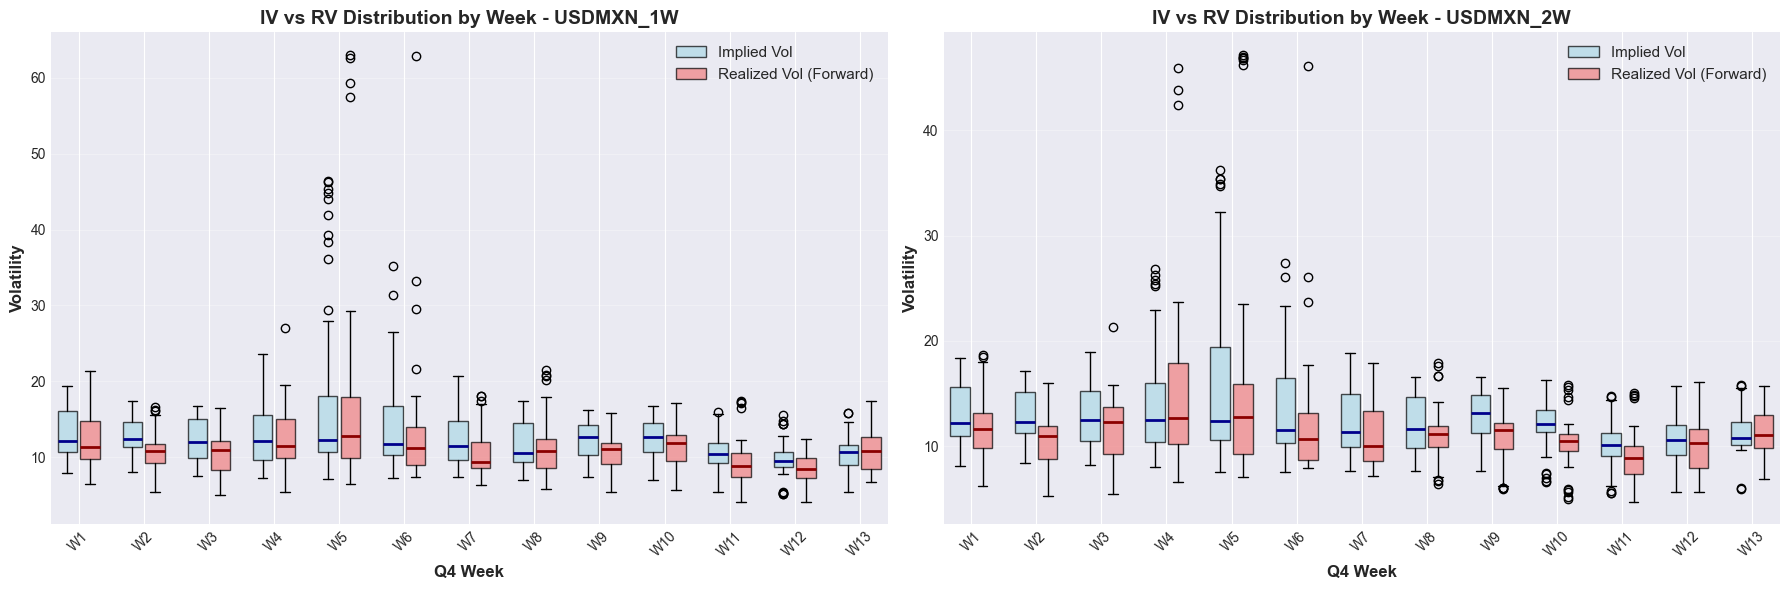

In [140]:
plot_iv_rv_weekly_distribution(q4_data, ccy='USDMXN', tenors=['1W', '2W'])

C:\Users\ntaylor\AppData\Local\Temp\ipykernel_15452\61900108.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Week', y='IV', ax=ax,
C:\Users\ntaylor\AppData\Local\Temp\ipykernel_15452\61900108.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Week', y='IV', ax=ax,


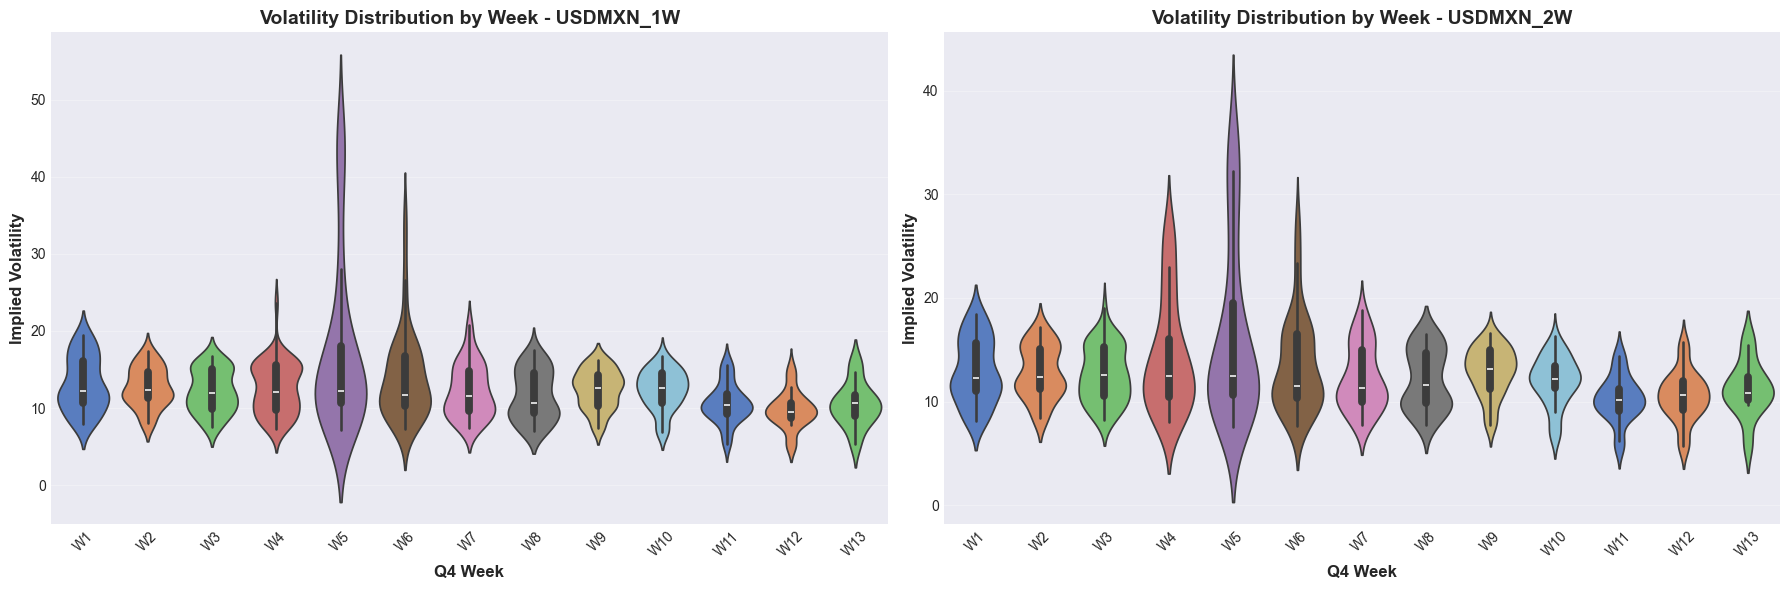

In [142]:
plot_violin_weekly_distribution(q4_data, ccy='USDMXN', tenors=['1W', '2W'])

In [ ]:
# =============================================================================================================================
# =============================================================================================================================
# =============================================================================================================================

In [210]:
# UK Budget dates
budget_dates = {
    '2015-03-18': 'Spring Budget 2015',
    '2015-07-08': 'Summer Budget 2015',
    '2017-11-22': 'Autumn Budget 2017',
    '2018-10-29': 'Budget 2018',
    '2020-03-11': 'Budget 2020',
    '2021-03-03': 'Budget 2021',
    '2022-09-23': 'Mini-Budget 2022',
    '2023-03-15': 'Spring Budget 2023',
    '2024-03-06': 'Spring Budget 2024',
    '2024-10-30': 'Autumn Budget 2024',
}

def get_budget_window_data(budget_date_str):
    """Get GBPUSD data from 1 month before to 2 weeks after budget"""
    
    budget_date = pd.to_datetime(budget_date_str)
    start_date = budget_date - timedelta(days=30)
    end_date = budget_date + timedelta(days=14)
    
    # Bloomberg query
    df = blp.bdh(
        tickers='GBPUSD Curncy',
        flds='PX_LAST',
        start_date=start_date.strftime('%Y-%m-%d'),
        end_date=end_date.strftime('%Y-%m-%d')
    )
    
    return df

# Collect all data
all_data = {}

for date_str, label in budget_dates.items():
    try:
        df = get_budget_window_data(date_str)
        all_data[label] = {
            'data': df,
            'budget_date': pd.to_datetime(date_str)
        }
    except Exception as e:
        print(f"Error fetching {label}: {e}")
results = []
for label, info in all_data.items():
    df = info['data']
    budget_date = info['budget_date']
    if len(df) > 0:
        df.index = pd.to_datetime(df.index)
        if isinstance(df.columns, pd.MultiIndex):
            df = df.droplevel(0, axis=1) if df.columns.nlevels > 1 else df
        if 'PX_LAST' in df.columns:
            price_col = 'PX_LAST'
        elif 'px_last' in df.columns:
            price_col = 'px_last'
        else:
            price_col = df.columns[0]
        
        budget_date_normalized = pd.Timestamp(budget_date.date())
        before_dates = df[df.index < budget_date_normalized]
        before_1m = before_dates.iloc[0][price_col] if len(before_dates) > 0 else None
        if budget_date_normalized in df.index:
            on_budget = df.loc[budget_date_normalized, price_col]
            if isinstance(on_budget, pd.Series):
                on_budget = on_budget.iloc[0]
        else:
            closest_idx = df.index.get_indexer([budget_date_normalized], method='nearest')[0]
            on_budget = df.iloc[closest_idx][price_col]
        after_dates = df[df.index > budget_date_normalized]
        after_2w = after_dates.iloc[-1][price_col] if len(after_dates) > 0 else None
        ret_1m_to_budget = ((on_budget - before_1m) / before_1m * 100) if before_1m else None
        ret_budget_to_2w = ((after_2w - on_budget) / on_budget * 100) if after_2w else None
        ret_1m_to_2w = ((after_2w - before_1m) / before_1m * 100) if before_1m and after_2w else None
        results.append({
            'Budget': label,
            'Date': budget_date.strftime('%Y-%m-%d'),
            '1M Before': before_1m,
            'On Budget': on_budget,
            '2W After': after_2w,
            'Return 1M→Budget (%)': ret_1m_to_budget,
            'Return Budget→2W (%)': ret_budget_to_2w,
            'Return 1M→2W (%)': ret_1m_to_2w})
    
results_df = pd.DataFrame(results)
results_df

,Budget,Date,1M Before,On Budget,2W After,Return 1M→Budget (%),Return Budget→2W (%),Return 1M→2W (%)
0,Spring Budget 2015,2015-03-18,1.5363,1.4978,1.4823,-2.506021,-1.034851,-3.514938
1,Summer Budget 2015,2015-07-08,1.5349,1.5361,1.5613,0.078181,1.640518,1.719982
2,Autumn Budget 2017,2017-11-22,1.3198,1.3325,1.3393,0.962267,0.510319,1.477497
3,Budget 2018,2018-10-29,1.3042,1.2793,1.2849,-1.909216,0.437739,-1.479834
4,Budget 2020,2020-03-11,1.2915,1.2820,1.1878,-0.735579,-7.347894,-8.029423
5,Budget 2021,2021-03-03,1.3663,1.3954,1.3966,2.129840,0.085997,2.217668
6,Mini-Budget 2022,2022-09-23,1.1799,1.0859,1.1086,-7.966777,2.090432,-6.042885
7,Spring Budget 2023,2023-03-15,1.2139,1.2057,1.2314,-0.675509,2.131542,1.441634
8,Spring Budget 2024,2024-03-06,1.2536,1.2731,1.2785,1.555520,0.424161,1.986280
9,Autumn Budget 2024,2024-10-30,1.3375,1.2962,1.2708,-3.087850,-1.959574,-4.986916
